<a href="https://colab.research.google.com/github/akwuphil/Airline-Customer-Satisfaction-Prediction-Logistic-Regression/blob/main/Phil_Customer_Churn_Prediction_Model_Using_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective

Predict whether a customer will leave a bank.

Target Variable

Exited

0 = Customer stays

1 = Customer leaves

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Churn_Modelling.csv')
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


(10000, 14)

In [ ]:
#Identifying Features
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df = df.drop(
    columns = ['RowNumber', 'CustomerId', 'Surname']
)

In [ ]:
#Feature Extraction
#Balance Per Product - Customers with many products but very little balance may
#behave differently

df["BalancePerProduct"] = df["Balance"] / (df["NumOfProducts"] + 1)

#This creates a new column called BalancePerProduct by dividing a customer's total bank bal by their total assets + 1

In [ ]:
#Age Groups
df['AgeGroup'] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["Young","Adult","Middle","Senior","Old"]
)

#Wealth Indicator
df['Wealth'] = df["Balance"] + df["EstimatedSalary"]

#encoding
df.select_dtypes(include="object")

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female
...,...,...
9995,France,Male
9996,France,Male
9997,France,Female
9998,Germany,Male


In [ ]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=['Geography', 'Gender', 'AgeGroup'])
drop_first=True

#Seperating Features and Target

X = df.drop("Exited", axis=1)
y = df["Exited"]

In [ ]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
 #Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    'CreditScore','Age','Tenure','Balance',
    'EstimatedSalary', 'BalancePerProduct','Wealth'
]

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

1. train Model
2. Make Predictions
3. Evaluate
4. Feature Importance - using logistic regression & Random Forest
5. Visualize feature importance


## Train the Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Make Prediction

In [ ]:
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)


## Evaluate Model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.8355
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1607
           1       0.68      0.31      0.43       393

    accuracy                           0.84      2000
   macro avg       0.76      0.64      0.66      2000
weighted avg       0.82      0.84      0.81      2000

Random Forest Accuracy: 0.868
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



## Feature Importance

In [ ]:
# Logistic Regression feature importance
log_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": log_reg.coef_[0]
}).sort_values(by="Importance", ascending=False)

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)


# Visualize Feature Importance

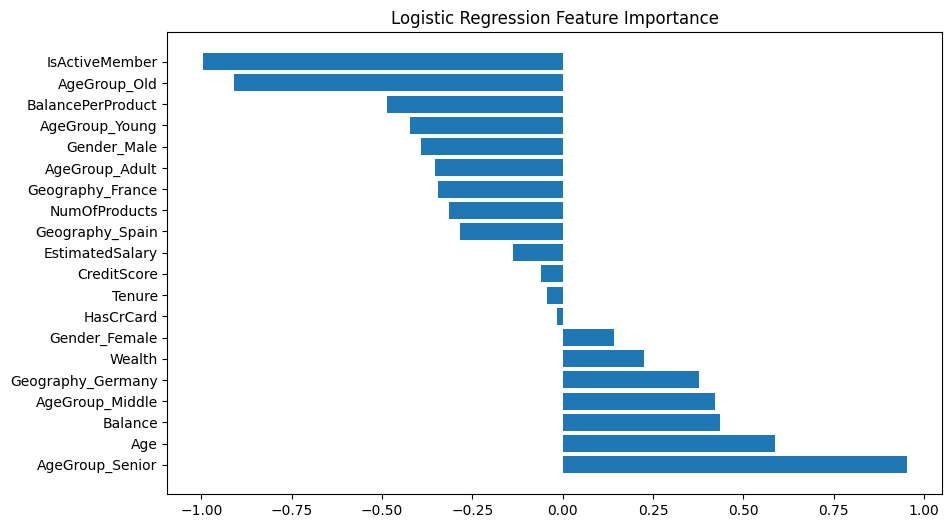

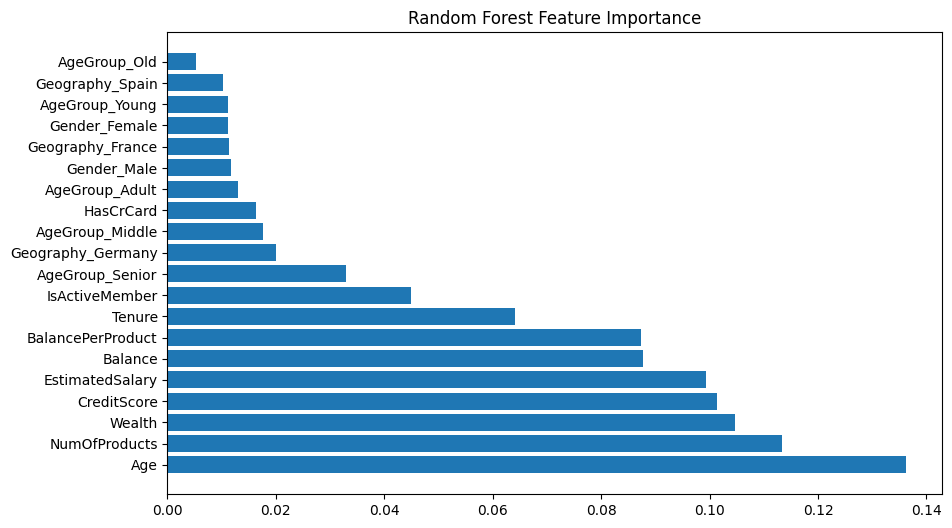

In [ ]:
# Logistic Regression
plt.figure(figsize=(10,6))
plt.barh(log_importance["Feature"], log_importance["Importance"])
plt.title("Logistic Regression Feature Importance")
plt.show()

# Random Forest
plt.figure(figsize=(10,6))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.show()
